# AG's News Topic Classification with RNN 📰 

![newspaper](https://www.shutterstock.com/image-photo/business-newspaper-isolated-on-white-600nw-1272343108.jpg)

## Dataset Overview - Business Problem

The **AG News** dataset contains news articles categorized into four topics: **World🌍**, **Sports⛹🏾‍♀️🏌🏾‍♂️🚴🏻**, **Business💼**, and **Science/Tech👨🏻‍💻**. 

#### Origin
AG is a collection of **1M+ news articles** gathered from over **2000 sources** via the academic news search engine *ComeToMyHead* (active since 2004).  
The dataset is publicly available for **research purposes only**, including tasks such as classification, clustering, information retrieval, and data compression.


#### Dataset Details
- **4 classes**
- **Training samples:** 120,000 (30,000 per class)  
- **Test samples:** 7,600 (1,900 per class)

#### 🗃️ File Structure
- **train.csv / test.csv** — Contain samples in CSV format with 3 columns:
  1. Class index (1-World, 2-Sports, 3-Business, 4-Sci/Tech)  
  2. Title  
  3. Description  


#### 🎯 Project Objective:

- The goal of this project is to develop and optimize an **RNN-based model for multiclass text classification** on the AG News dataset. 

- The pipeline includes **text vectorization, sequence padding, and hyperparameter tuning with Keras Tuner** to identify the best-performing architecture.

- Model performance is assessed using **Accuracy, AUC, ROC curves**, and a detailed **classification report** to ensure robust generalization across all four news categories.

# 1. Data Loading & Initial Inspection 📥

In [ ]:
# Data Preprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Modelling
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN,Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Model evaluation
from sklearn.metrics import classification_report,roc_curve,auc,confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import RocCurveDisplay

import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv('/kaggle/input/ag-news-classification-dataset/train.csv')

train.head(2)

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...


In [3]:
test = pd.read_csv('/kaggle/input/ag-news-classification-dataset/test.csv')

test.head(2)

,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."


In [4]:
print(f"Train dataset shape:{train.shape}")
print(f"Test dataset shape:{test.shape}")

Train dataset shape:(120000, 3)
Test dataset shape:(7600, 3)


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Class Index  120000 non-null  int64 
 1   Title        120000 non-null  object
 2   Description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Class Index  7600 non-null   int64 
 1   Title        7600 non-null   object
 2   Description  7600 non-null   object
dtypes: int64(1), object(2)
memory usage: 178.3+ KB


In [7]:
print("Train DataFrame null value check:")
print(train.isnull().sum())

print("\nTest DataFramenull value check:")
print(test.isnull().sum())

Train DataFrame null value check:
Class Index    0
Title          0
Description    0
dtype: int64

Test DataFramenull value check:
Class Index    0
Title          0
Description    0
dtype: int64


In [8]:
print("Test :",test['Class Index'].value_counts())
print("\nTrain :",train['Class Index'].value_counts())

Test : Class Index
3    1900
4    1900
2    1900
1    1900
Name: count, dtype: int64

Train : Class Index
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64


In [9]:
x_train = train.iloc[:,1:]
y_train = train.iloc[:,0:1]

x_test = test.iloc[:,1:]
y_test = test.iloc[:,0:1]

In [10]:
print("Test :",y_test.value_counts())
print("\nTrain :",y_train['Class Index'].value_counts())

Test : Class Index
1              1900
2              1900
3              1900
4              1900
Name: count, dtype: int64

Train : Class Index
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64


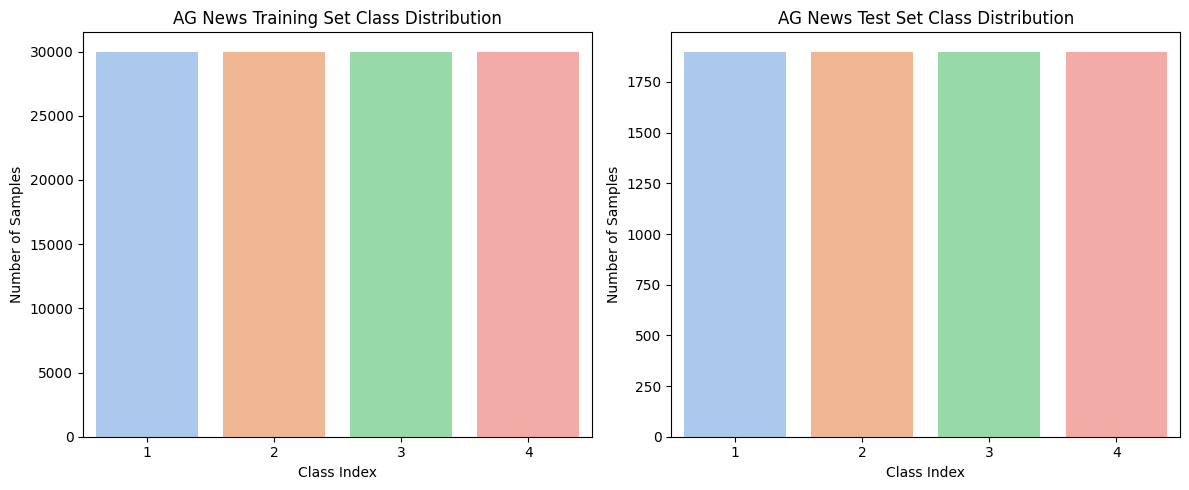

In [11]:
sns.set_palette("pastel")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  #  1 row, 2 columns

# Train set
sns.countplot(x=y_train.squeeze(), ax=axes[0])
axes[0].set_xlabel('Class Index')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('AG News Training Set Class Distribution')

# Test set
sns.countplot(x=y_test.squeeze(), ax=axes[1])
axes[1].set_xlabel('Class Index')
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('AG News Test Set Class Distribution')

plt.tight_layout()
plt.show()

# 2. One-Hot-Encoding

`to_categorical` converts integer class labels into **one-hot vectors** (e.g., `[0,2,1] → [[1,0,0],[0,0,1],[0,1,0]]`).

**Note:** The class labels in the dataset range from 1 to 4, but `to_categorical` expects labels starting at 0. Therefore, we subtract 1 from the labels before one-hot encoding.


In [12]:
# One-hot encode
y_train = to_categorical(y_train.squeeze()-1)
y_test = to_categorical(y_test.squeeze()-1)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (120000, 4)
y_test shape: (7600, 4)


# 3. Text Preprocessing 🛠️

## 3.1.Combining and Tokenizing

We combine the `Title` and `Description` columns to create a single text input for the model.  
Then, we tokenize the combined text for use in an RNN model.

**Steps:**
1. Concatenate `Title` and `Description`.
2. Fit a tokenizer on the combined text.
3. Convert text to sequences for model input.

-----

##### Why Tokenization is Necessary ?

Tokenization converts words or characters into **unique numbers** so that the model can process text data.

Example:

```
["world", "hello", "business", "sports"]

world -> 1
hello -> 2
business -> 3
sports -> 4
```

These numbers can then be converted into **vectors** by the Embedding layer, which the model can use as input.


In [13]:
# Title + Description 
x_train_texts = (x_train['Title'] + " " + x_train['Description']).values
x_test_texts = (x_test['Title'] + " " + x_test['Description']).values


# Parameters
vocab_size = 10000 # 10000 most frequently used words
maxlen = 100  
oov_token = "<OOV>"


tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)
# Learn word frequency from training data
tokenizer.fit_on_texts(x_train_texts)

# Text -> numbers
train_sequences = tokenizer.texts_to_sequences(x_train_texts)
test_sequences = tokenizer.texts_to_sequences(x_test_texts)

#### Handling Out-of-Vocabulary Words `oov_token` 

**Without oov_token (default)**: unknown words are ignored, which can cause information loss.

Example:

Vocabulary: `["apple","cat", "dog"]`  
Input: `"I love dog"`  
Output: `[2]` → `"I"` and `"love"` are discarded.

---

**With oov_token="\<OOV>"**: unknown words are replaced with a special token, preserving all words.

Example:

Input: `"I love dog"`  
Output: `["<OOV>", "<OOV>", 2]`


## 3.2.Padding 📏

### Why is padding necessary?

Texts can vary in length:

```
‘Hello world’ -> 2 words
‘Hello everyone in the world’ -> 5 words
```

- **Neural networks require a fixed input size.**
  
- Therefore, we pad short texts with zeros or truncate long texts.

----

**`padding='post'`**: Adds zeros **at the end** of shorter sequences.

Example:
[4, 7, 9] → [4, 7, 9, 0, 0]

**`truncating='post'`**: Cuts longer sequences **from the end**.

Example:
[3, 8, 1, 5, 9, 6] → [3, 8, 1, 5, 9]

In [14]:
# Padding
x_train_padded = pad_sequences(train_sequences, maxlen=maxlen, padding='post', truncating='post')
x_test_padded = pad_sequences(test_sequences, maxlen=maxlen, padding='post', truncating='post')

print("x_train_padded shape:", x_train_padded.shape)
print("x_test_padded shape:", x_test_padded.shape)

x_train_padded shape: (120000, 100)
x_test_padded shape: (7600, 100)


## 3.3.Text Length Distribution Analysis (Title + Description)

In [15]:
train_lengths = [len(text.split()) for text in x_train_texts]
test_lengths = [len(text.split()) for text in x_test_texts]

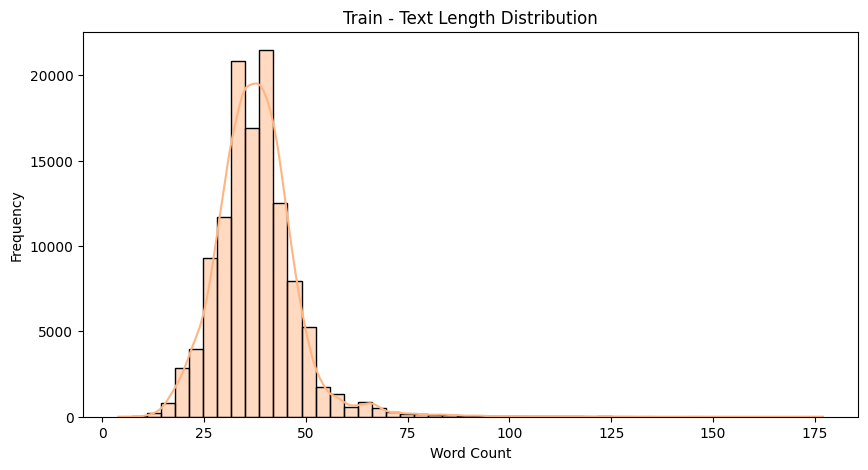

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(train_lengths, bins=50, kde=True, color=sns.color_palette("pastel")[1])
plt.title("Train - Text Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

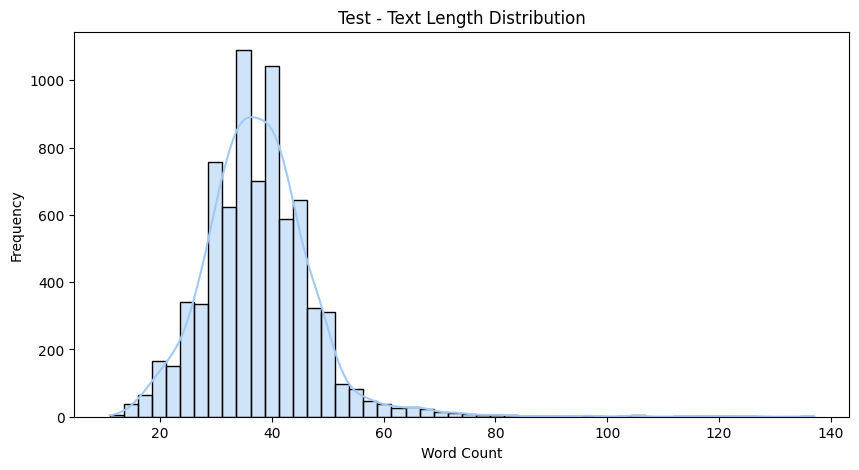

In [17]:
plt.figure(figsize=(10,5))
sns.histplot(test_lengths, bins=50, kde=True)
plt.title("Test - Text Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

# 4. RNN Model Architecture 🏗️

- The tokenized and padded numbers are fed into the Embedding layer.

- **The Embedding layer converts each word into a vector.**

- The **SimpleRNN** takes these vectors in order and tries to **learn the meaning of the text.**

In [18]:
def build_model(hp):
    
    model=Sequential() 

    # Embeding layer :  words -> vectors
    model.add(Embedding(input_dim=10000,
                        output_dim=hp.Int("embeding_output", 
                                          min_value=64,
                                          max_value=128,step=32),# 64,96,128
                                          input_length = maxlen))

    # simpleRNN layer
    model.add(SimpleRNN(units=hp.Int("rnn_units",min_value=64,max_value=256,step=32))) #  64,96,128,..,256

    # dropout : prevent overfitting
    model.add(Dropout(rate=hp.Float("dropout_rate",min_value=0.2,max_value=0.5,step=0.1) # 0.2, 0.3,0.4,0.5
    ))
    # output layer
    model.add(Dense(units=4,activation="softmax")) 
    
    hp_clipnorm = hp.Choice('clipnorm_rate', values=[1.0,2.0,3.0])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4,clipnorm=hp_clipnorm),
                  loss="categorical_crossentropy", # multiclass classification + one-hot encoding
                  metrics=["accuracy","AUC"]) 

    return model


# 5. Hyperparameter Search ⚙️🔎

- **keras_tuner** enables automated hyperparameter optimization for Keras models.
- **RandomSearch** explores random combinations of hyperparameters within the defined ranges to find the best model configuration.



In [19]:
!pip install keras-tuner -q

In [20]:
import keras_tuner as kt
from keras_tuner.tuners import RandomSearch

In [ ]:
tuner = RandomSearch(
    build_model, # model 
    objective="val_accuracy", 
    max_trials=30, # 30 different models will be tested.
    executions_per_trial= 1, # 1 training - Try each model once
    directory =  "/kaggle/working/rnn_tuner_directory", 
    project_name = "ag_news_rnn" 
)

early_stopping = EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True)

In [22]:
tuner.search(x_train_padded,y_train,
             epochs=15,
             validation_split=0.2, 
             callbacks=[early_stopping]
             )

Trial 30 Complete [00h 03m 16s]
val_accuracy: 0.8647500276565552

Best val_accuracy So Far: 0.8885416388511658
Total elapsed time: 01h 50m 18s


In [23]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_hps.values

{'embeding_output': 128,
 'rnn_units': 160,
 'dropout_rate': 0.30000000000000004,
 'clipnorm_rate': 1.0}

In [ ]:
tuner.results_summary() # all training parameters and results

In [25]:
best_model = tuner.get_best_models(num_models=1)[0]

In [26]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (32, 100, 128)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (32, 160)              │        46,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 160)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 4)                │           644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,326,884 (5.06 MB)

 Trainable params: 1,326,884 (5.06 MB)

 Non-trainable params: 0 (0.00 B)

# 6. Evaluate Best Model 📊📉

In [27]:
acc,loss,auc_score = best_model.evaluate(x_test_padded,y_test)

238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - AUC: 0.9756 - accuracy: 0.8915 - loss: 0.3542


In [28]:
y_pred_prob = best_model.predict(x_test_padded)
y_pred_prob[:5] 

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


array([[3.0290384e-02, 4.9893926e-03, 9.5533681e-01, 9.3834270e-03],
       [3.7928190e-02, 6.2094191e-03, 7.0068971e-03, 9.4885546e-01],
       [3.0986486e-02, 4.6913969e-04, 1.3554795e-01, 8.3299643e-01],
       [3.3243465e-01, 1.5016466e-01, 4.6081418e-01, 5.6586485e-02],
       [3.1809498e-02, 6.2001962e-04, 2.5395518e-02, 9.4217497e-01]],
      dtype=float32)

## 6.1.ROC Curves

`RocCurveDisplay.from_predictions` : For each class, the **true binary labels** and the **predicted class probabilities** are compared across thresholds to compute TPR/FPR and plot the ROC curve.

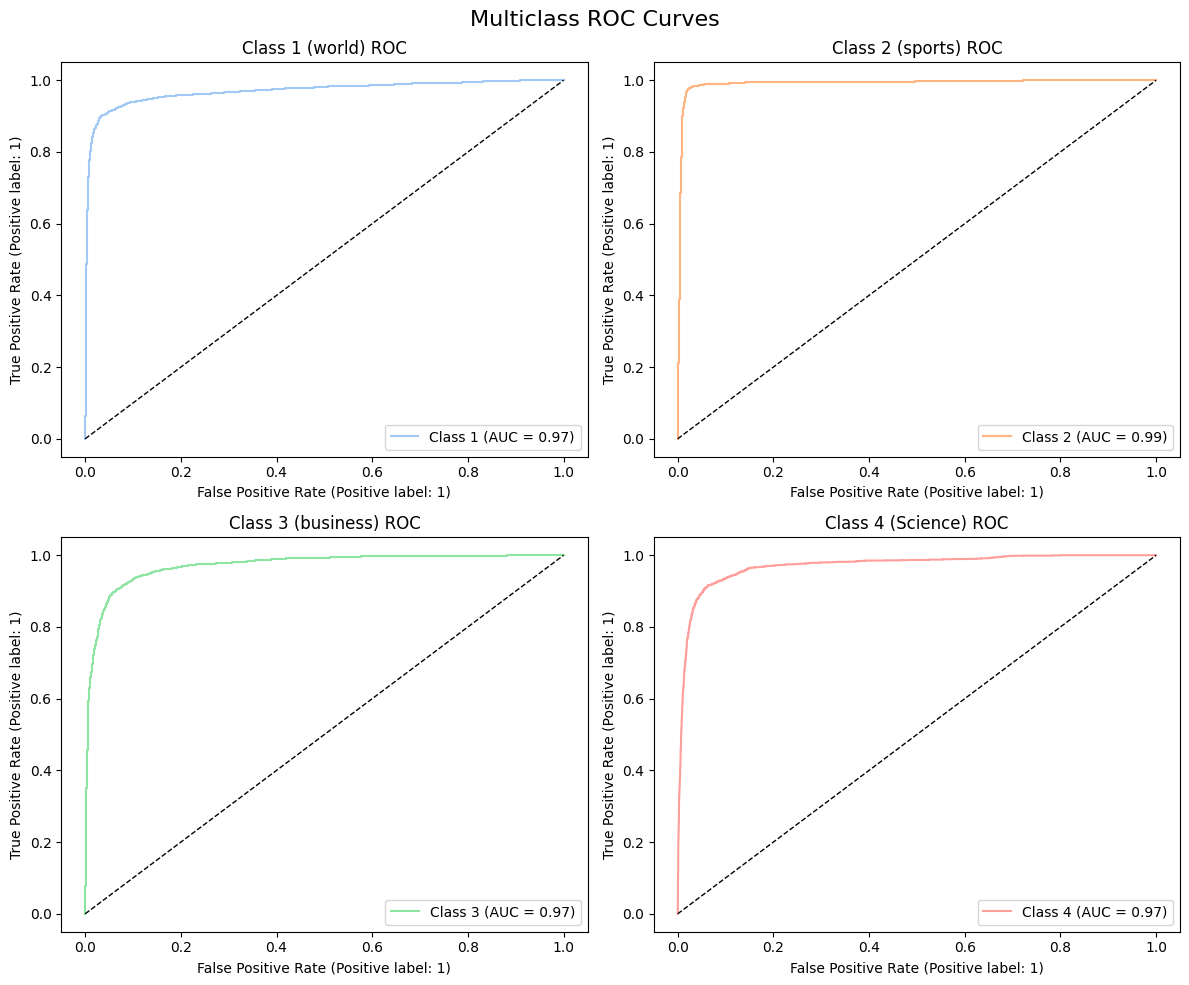

In [29]:
# y_test: actual labels (binary format:one hot encoding)
# y_pred_prob: model class probabilities (n_samples, n_classes)

class_names=["world", "sports", "business", "Science"]

pastel_colors = sns.color_palette("pastel", 4)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))


axes = axes.flatten() 

# AG NEWS -> classes 0-3
for i in range(4):
    # ROC curve for each class
    RocCurveDisplay.from_predictions(
        y_test[:, i], 
        y_pred_prob[:, i],
        name=f"Class {i+1}",
        color=pastel_colors[i],
        ax=axes[i]             
    )
    
    axes[i].plot([0, 1], [0, 1], "k--", lw=1)
    axes[i].set_title(f"Class {i+1} ({class_names[i]}) ROC")

plt.suptitle("Multiclass ROC Curves", fontsize=16)
plt.tight_layout()
plt.show()

## 6.2.Classification Report

In [30]:
y_pred = np.argmax(y_pred_prob, axis=1) 

y_test = np.argmax(y_test, axis=1) 

In [31]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       world       0.91      0.89      0.90      1900
      sports       0.95      0.95      0.95      1900
    business       0.84      0.89      0.87      1900
     Science       0.89      0.86      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



The model performs well across all classes, achieving an **overall accuracy of 0.90.**

- Highest performance is on **Sports (F1-score 0.95)**, while **Business and Science** are slightly lower but still strong **(F1-score 0.87)**.

- Balanced performance is indicated by similar macro and weighted averages.

## 6.3.Confusion Matrix

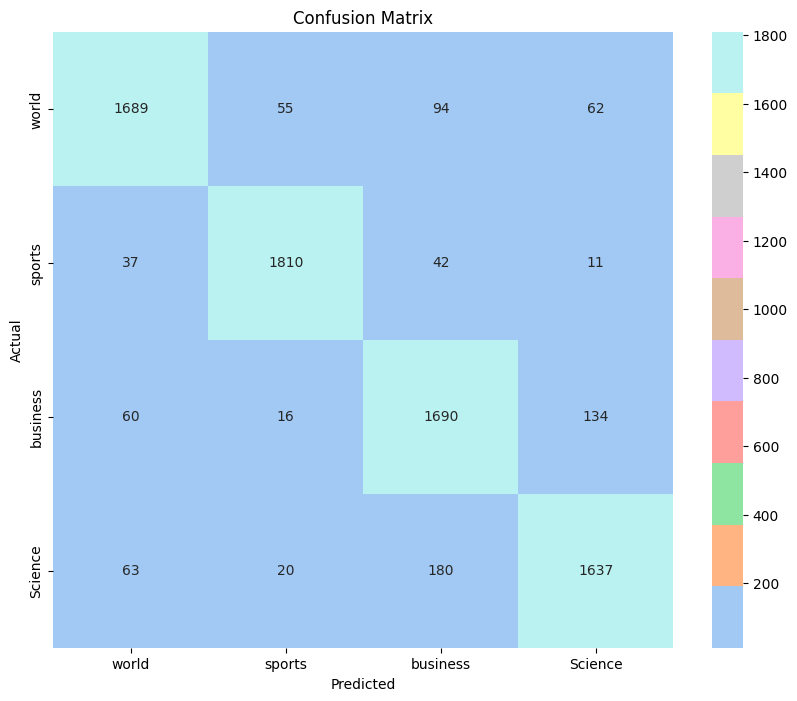

In [32]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap=sns.color_palette("pastel"), xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# Conclusion ✅

- The RNN-based model achieved strong performance on the AG News dataset with **90% accuracy**.
- Hyperparameter tuning helped optimize the architecture, and the model demonstrates balanced classification across all four categories.